In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick
from dmri.simulators.local_signal_models.distributional_models import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:20: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere_default = get_sphere("symmetric724")
/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:23: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  big_sphere = get_sphere("repulsion724")


In [3]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = np.random.randn(100, 3)
bvecs = bvecs / np.linalg.norm(bvecs, axis=1)[:, None]


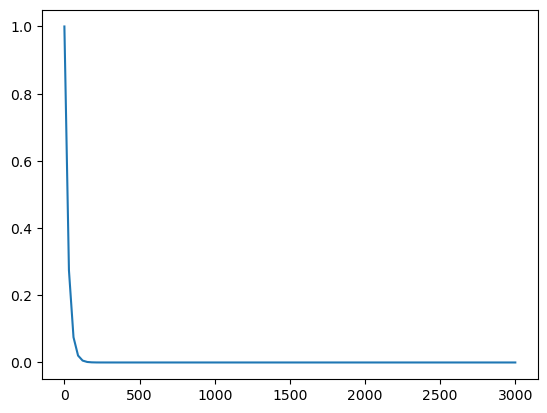

In [4]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(bvals, bvecs)

plt.plot(bvals, signal)

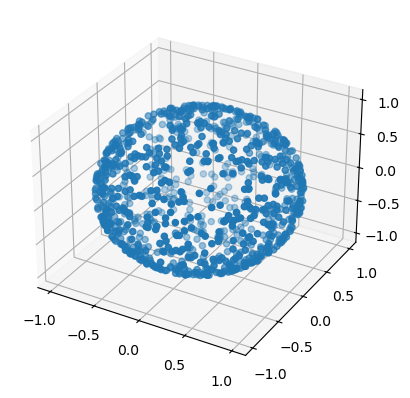

In [5]:
directions = jax.vmap(ball.fod_sample)(jax.random.split(jax.random.key(0), 1000))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(directions[:, 0], directions[:, 1], directions[:, 2])

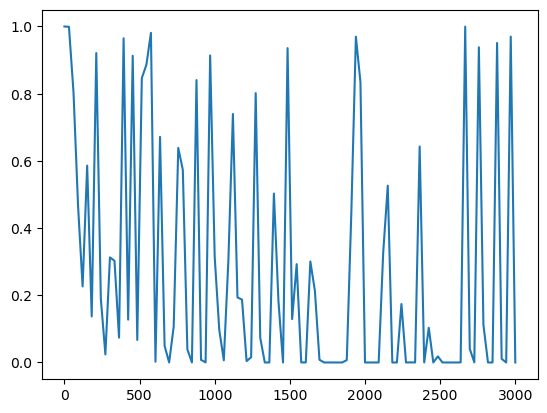

In [6]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(bvals, bvecs)

plt.plot(bvals, signal)

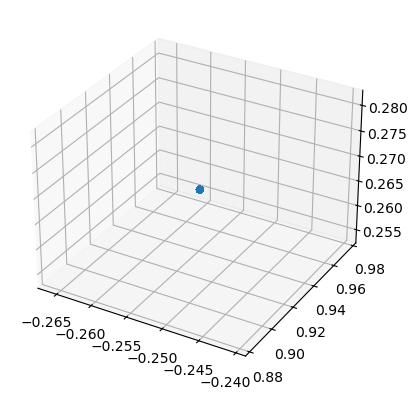

In [7]:
directions = jax.vmap(stick.fod_sample)(jax.random.split(jax.random.key(0), 1000))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(directions[:, 0], directions[:, 1], directions[:, 2])

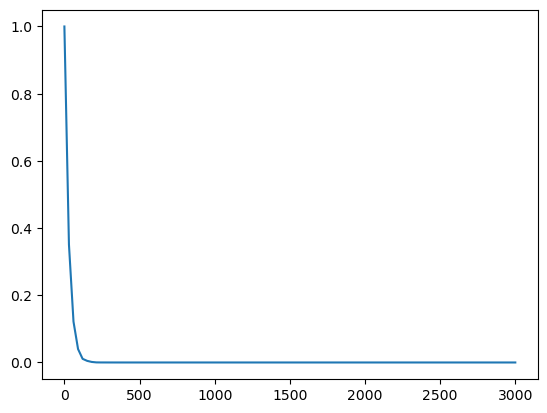

In [8]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(bvals, bvecs)

plt.plot(bvals, signal)

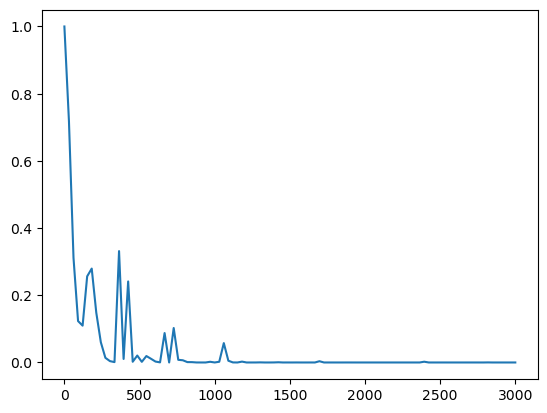

In [9]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(bvals, bvecs)

plt.plot(bvals, signal)

/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:20: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  sphere_default = get_sphere("symmetric724")
/root/simformer_model_selection/dmri/dmri/simulators/sphereical_distributions.py:23: UserWarning: Pass ['name'] as keyword args. From version 2.0.0 passing these as positional arguments will result in an error. 
  big_sphere = get_sphere("repulsion724")


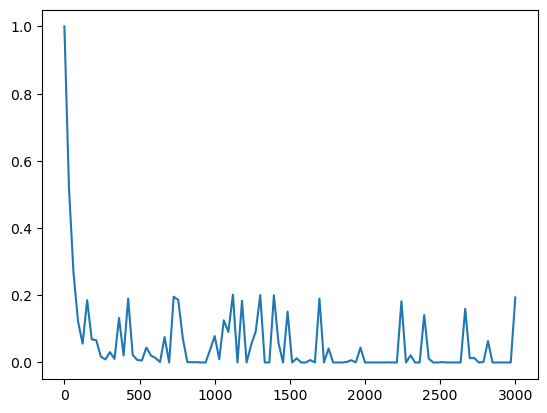

In [10]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(bvals, bvecs, None)

plt.plot(bvals, signal)

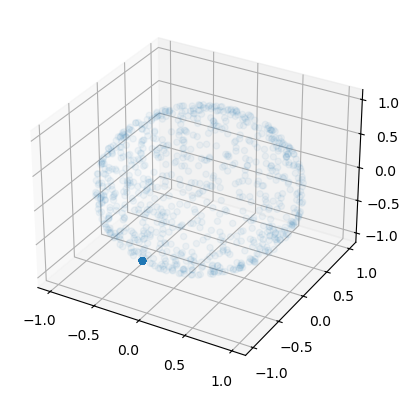

In [11]:
directions = jax.vmap(ball_stick.fod_sample)(jax.random.split(jax.random.key(0), 1000))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(directions[:, 0], directions[:, 1], directions[:, 2], alpha=0.05)

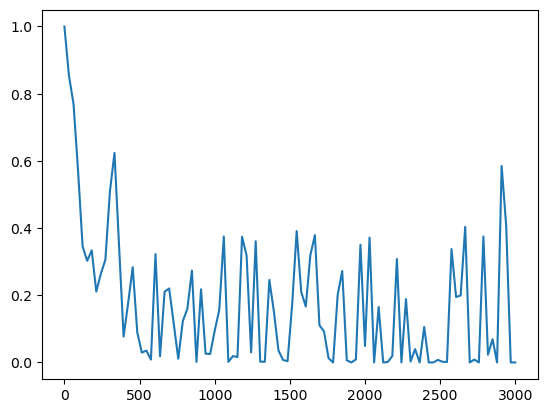

In [12]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(bvals, bvecs, None)

plt.plot(bvals, signal)

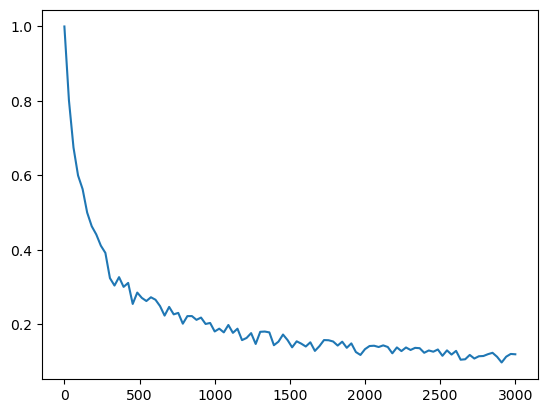

In [13]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(bvals, bvecs)
plt.plot(bvals, signal)

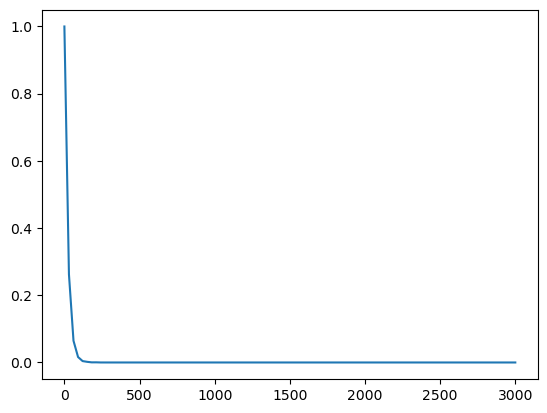

In [14]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(bvals, bvecs)
plt.plot(bvals, signal)

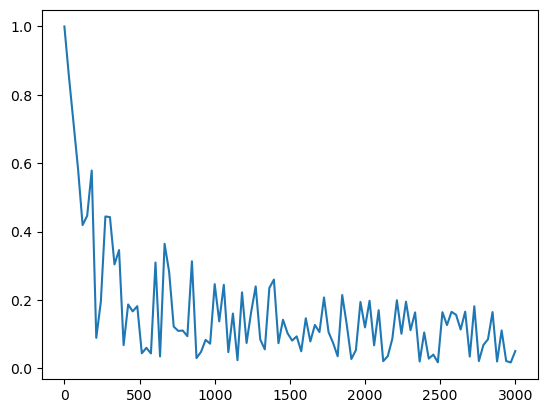

In [23]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(bvals, bvecs)
plt.plot(bvals, signal)

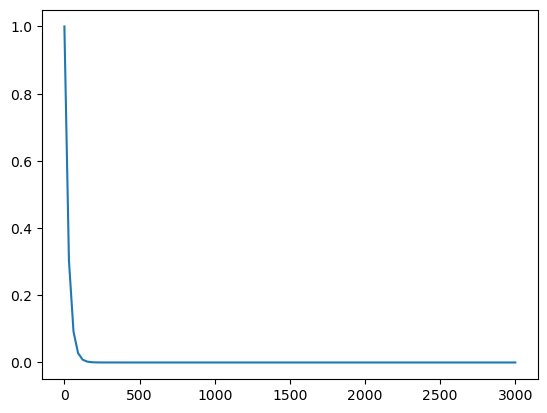

In [33]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(bvals, bvecs)
plt.plot(bvals, signal)

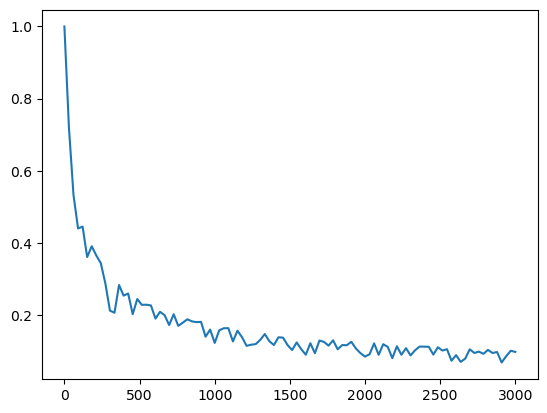

In [37]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(bvals, bvecs)
plt.plot(bvals, signal)

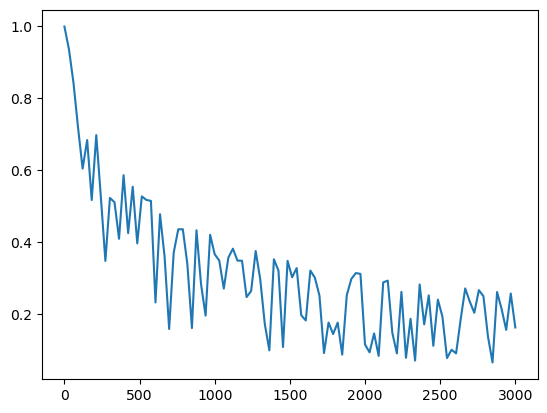

In [42]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(bvals, bvecs)
plt.plot(bvals, signal)